# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

**1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?**

Adding a penalty that grows with the size of the coefficients discourages the model from assigning large weights to any individual feature. Without a penalty, OLS can fit training data perfectly by spreading weight across many predictors, including ones that are only coincidentally correlated with the outcome. The penalty forces the model to only use large coefficients when the evidence for them is strong, which reduces overfitting and produces estimates that generalize better to new data.

**2. How does regularization provide a way of exploring the bias-variance trade-off?**

The penalty strength alpha directly controls the bias-variance tradeoff. At alpha equal to zero there is no regularization and the model is high variance, fitting noise in the training data. As alpha increases, coefficients are shrunk toward zero, reducing variance at the cost of introducing bias. Cross-validating over a grid of alpha values lets us find the point that minimizes expected test error, navigating the tradeoff in a data-driven way.

**3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?**

LASSO uses an L1 penalty (sum of absolute values of coefficients) while Ridge uses an L2 penalty (sum of squared coefficients). The key practical difference is that LASSO shrinks some coefficients exactly to zero, performing variable selection, while Ridge shrinks all coefficients toward zero but rarely to exactly zero. LASSO tends to produce sparse models with a small number of selected features, while Ridge retains all features with smaller weights. LASSO is preferable when only a few predictors are truly relevant, while Ridge works better when many predictors each contribute a small amount.

**4. How do we typically scale variables for use in regularized regression? Why?**

Variables are typically z-score normalized using StandardScaler before regularized regression, subtracting the mean and dividing by the standard deviation. This is necessary because the penalty treats all coefficients equally, so if features are on different scales, the penalty will disproportionately shrink coefficients for features measured in larger units. Standardizing puts all features on the same scale so the penalty is applied fairly across all of them.

**5. How is the penalty $\alpha$ typically selected?**

The penalty alpha is typically selected using cross-validation. A grid of candidate alpha values is evaluated by fitting the model on training folds and measuring MSE on held-out folds, and the alpha that minimizes average CV MSE is chosen. This is what LassoCV and RidgeCV implement automatically.

**6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?**

No, the penalty term is not included when evaluating cross-validated MSE. The penalty is a regularization device used during fitting to constrain coefficient size, not a measure of prediction error. CV MSE is meant to estimate how well the model predicts on new data, so it should only measure the discrepancy between predictions and actual outcomes, not the size of the coefficients.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

             feature      ols_coef
0        Mileage_Run  7.861191e+05
1                Age -2.141229e+05
2      Mileage_Run^2 -1.783803e+05
3    Mileage_Run Age -1.453125e+06
4              Age^2  2.789820e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.109725e+05
7  Mileage_Run Age^2  6.186680e+05
8              Age^3 -1.724494e+05


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 113886852965.03125, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 132795967206.25, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 134831568431.84375, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Object


Optimal alpha: 112.8838


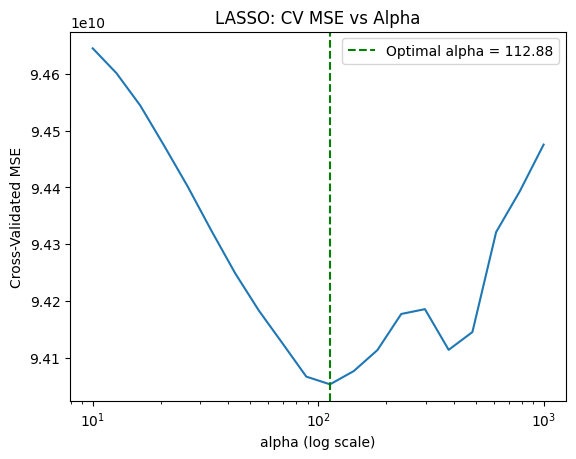

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.340e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.440e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.520e+11, tolerance: 1.316e

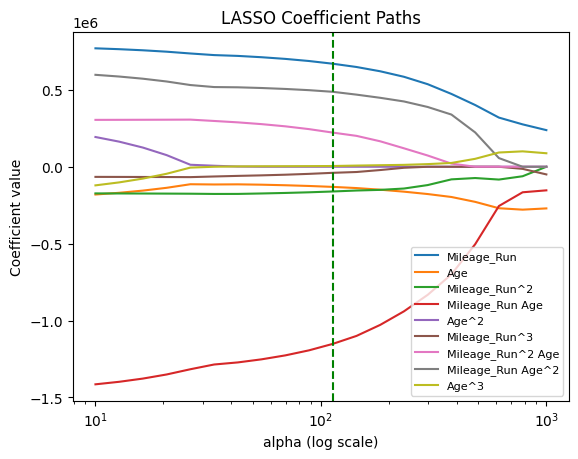

             feature      ols_coef    lasso_coef
0        Mileage_Run  7.861191e+05  6.700829e+05
1                Age -2.141229e+05 -1.309727e+05
2      Mileage_Run^2 -1.783803e+05 -1.607844e+05
3    Mileage_Run Age -1.453125e+06 -1.151929e+06
4              Age^2  2.789820e+05  0.000000e+00
5      Mileage_Run^3 -6.514490e+04 -3.945806e+04
6  Mileage_Run^2 Age  3.109725e+05  2.221205e+05
7  Mileage_Run Age^2  6.186680e+05  4.874554e+05
8              Age^3 -1.724494e+05  4.838281e+03

Features selected: 8
Features zeroed out: 1
Proportion zeroed: 11.11%


In [12]:
df = pd.read_csv('./data/cars_hw.csv')
df['Age'] = 2025 - df['Make_Year']

y = df['Price']
X_raw = df[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_raw)

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_poly)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

# Part 2 - OLS
lin_reg = LinearRegression()
lin_reg.fit(X_sc, y)

coef_df = pd.DataFrame({'feature': feature_names, 'ols_coef': lin_reg.coef_})
print(coef_df)

# Part 3 - LassoCV
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(cv=20, alphas=alphas, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)
alpha_star = lasso_cv.alpha_
print(f'\nOptimal alpha: {alpha_star:.4f}')

# Part 4 - CV MSE plot
cv_mse_by_alpha = np.mean(lasso_cv.mse_path_, axis=1)
sns.lineplot(x=lasso_cv.alphas_, y=cv_mse_by_alpha)
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5, label=f'Optimal alpha = {alpha_star:.2f}')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('LASSO: CV MSE vs Alpha')
plt.legend()
plt.show()

# Part 5 - Coefficient paths
coefs = []
for alpha in lasso_cv.alphas_:
    reg = Lasso(alpha=alpha, max_iter=10000)
    reg.fit(X_sc, y)
    coefs.append(reg.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], label=feature_names[i])
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.legend(fontsize=8)
plt.show()

# Parts 6 & 7 - Selected features and comparison
final_lasso = Lasso(alpha=alpha_star, max_iter=10000)
final_lasso.fit(X_sc, y)
coefs_star = final_lasso.coef_

coef_comparison = pd.DataFrame({
    'feature': feature_names,
    'ols_coef': lin_reg.coef_,
    'lasso_coef': coefs_star
})
print(coef_comparison)
print(f'\nFeatures selected: {np.sum(coefs_star != 0)}')
print(f'Features zeroed out: {np.sum(coefs_star == 0)}')
print(f'Proportion zeroed: {np.mean(coefs_star == 0):.2%}')

The `Mileage_Run Age` interaction has a negative coefficient of -1,453,125 in OLS, meaning vehicles that are both older and higher mileage are predicted to have lower prices, which makes intuitive sense as the two depreciation factors compound each other.

LassoCV selects an optimal alpha of 112.88. The CV MSE plot shows a clear U-shape, with high error at small alpha (overfitting), a minimum at the optimal value, and rising error at large alpha (underfitting). The coefficient path plot shows most features are stable across alpha values, with `Mileage_Run Age` carrying the largest negative coefficient throughout.

At the optimal alpha, 8 of 9 features are retained and only `Age^2` is zeroed out (11.1% discarded), suggesting the quadratic age term adds little beyond what is captured by the linear `Age` term and its interactions. No coefficients increase in magnitude from OLS to LASSO, as expected since LASSO only shrinks. The one notable change is `Age^3`, which flips sign from -172,449 in OLS to +4,838 in LASSO, suggesting it was capturing noise in OLS rather than a real relationship.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

                                   feature  ols_coef
0                                      age  1.539156
1                        ejection_fraction -2.192494
2                         serum_creatinine -0.853588
3                                    age^2 -3.678654
4                    age ejection_fraction -0.600918
5                     age serum_creatinine  1.841563
6                      ejection_fraction^2  3.430976
7       ejection_fraction serum_creatinine  2.673394
8                       serum_creatinine^2 -2.647041
9                                    age^3  1.993135
10                 age^2 ejection_fraction  0.908026
11                  age^2 serum_creatinine -0.697522
12                 age ejection_fraction^2 -0.081206
13  age ejection_fraction serum_creatinine -1.577665
14                  age serum_creatinine^2  1.284099
15                     ejection_fraction^3 -1.250341
16    ejection_fraction^2 serum_creatinine -1.270043
17    ejection_fraction serum_creatinine^2  1.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.1655699255817744, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.019422437013997, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.954870463666694, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Conv


Optimal alpha: 0.005736


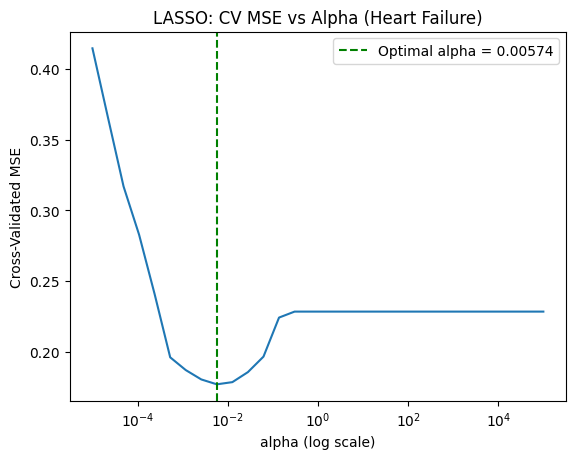

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.389e-01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.576e+00, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+01, tolerance: 6.518e

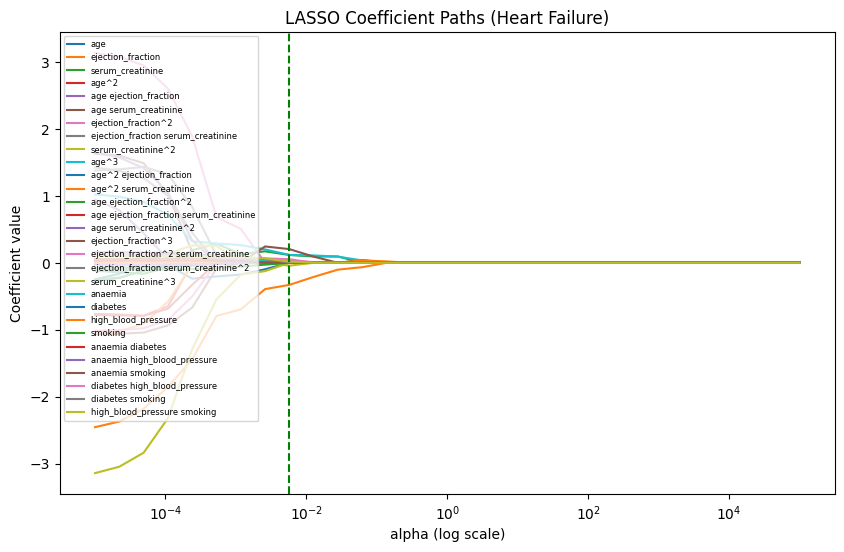

                                   feature  ols_coef  lasso_coef
0                                      age  1.539156   -0.000000
1                        ejection_fraction -2.192494   -0.329656
2                         serum_creatinine -0.853588    0.116875
3                                    age^2 -3.678654    0.000000
4                    age ejection_fraction -0.600918   -0.000000
5                     age serum_creatinine  1.841563    0.000000
6                      ejection_fraction^2  3.430976    0.000000
7       ejection_fraction serum_creatinine  2.673394    0.000000
8                       serum_creatinine^2 -2.647041   -0.000000
9                                    age^3  1.993135    0.117992
10                 age^2 ejection_fraction  0.908026    0.000000
11                  age^2 serum_creatinine -0.697522    0.000000
12                 age ejection_fraction^2 -0.081206    0.000000
13  age ejection_fraction serum_creatinine -1.577665    0.000000
14                  age s

In [19]:
df3 = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

continuous = df3[['age', 'ejection_fraction', 'serum_creatinine']]
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_cont = poly3.fit_transform(continuous)
scaler3 = StandardScaler()
X_cont_sc = scaler3.fit_transform(X_cont)

categorical = df3[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(categorical)

X3 = np.concatenate([X_cont_sc, X_cat], axis=1)
cont_names = poly3.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
cat_names = poly_cat.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
all_names = np.concatenate([cont_names, cat_names])
y3 = df3['DEATH_EVENT']

# Part 2 - OLS
lin_reg3 = LinearRegression()
lin_reg3.fit(X3, y3)
coef_df3 = pd.DataFrame({'feature': all_names, 'ols_coef': lin_reg3.coef_})
print(coef_df3.to_string())

# Part 3 - LassoCV
alphas3 = np.logspace(-5, 5, 30)
lasso_cv3 = LassoCV(cv=20, alphas=alphas3, random_state=100, max_iter=10000)
lasso_cv3.fit(X3, y3)
alpha_star3 = lasso_cv3.alpha_
print(f'\nOptimal alpha: {alpha_star3:.6f}')

# Part 4 - CV MSE plot
cv_mse_by_alpha3 = np.mean(lasso_cv3.mse_path_, axis=1)
sns.lineplot(x=lasso_cv3.alphas_, y=cv_mse_by_alpha3)
plt.axvline(x=alpha_star3, color='green', linestyle='--', linewidth=1.5, label=f'Optimal alpha = {alpha_star3:.5f}')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('LASSO: CV MSE vs Alpha (Heart Failure)')
plt.legend()
plt.show()

# Part 5 - Coefficient paths
coefs3 = []
for alpha in lasso_cv3.alphas_:
    reg = Lasso(alpha=alpha, max_iter=10000)
    reg.fit(X3, y3)
    coefs3.append(reg.coef_)
coefs3 = np.array(coefs3)

plt.figure(figsize=(10, 6))
for i in range(coefs3.shape[1]):
    plt.plot(lasso_cv3.alphas_, coefs3[:, i], label=all_names[i])
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths (Heart Failure)')
plt.axvline(x=alpha_star3, color='green', linestyle='--')
plt.legend(fontsize=6)
plt.show()

# Part 6 - Feature comparison
final_lasso3 = Lasso(alpha=alpha_star3, max_iter=10000)
final_lasso3.fit(X3, y3)
coefs_star3 = final_lasso3.coef_

coef_comparison3 = pd.DataFrame({
    'feature': all_names,
    'ols_coef': lin_reg3.coef_,
    'lasso_coef': coefs_star3
})
print(coef_comparison3.to_string())
print(f'\nFeatures selected: {np.sum(coefs_star3 != 0)}')
print(f'Features zeroed out: {np.sum(coefs_star3 == 0)}')
print(f'Proportion zeroed: {np.mean(coefs_star3 == 0):.2%}')

The OLS coefficients show some counterintuitive signs. `serum_creatinine` has a negative coefficient (-0.854) even though higher creatinine is a known marker of kidney dysfunction and typically associated with higher mortality risk. Similarly, `ejection_fraction^2` is large and positive (3.431) while the linear `ejection_fraction` term is negative, which creates a confusing nonlinear pattern. These contradictions arise because OLS is distributing effects across correlated polynomial terms and interactions, which can produce unstable and hard to interpret coefficients. Higher-order terms and interactions may resolve this by allowing the model to capture the true nonlinear relationship, for example that creatinine's effect on mortality changes depending on age or ejection fraction.

LassoCV selects an optimal alpha of 0.005736. The CV MSE plot shows a steep decline from small alpha (overfitting) to the minimum at the optimal value, then a plateau as all coefficients are pushed to zero (underfitting). The coefficient path plot shows most features collapsing to zero well before the optimal alpha, with only a handful surviving.

At the optimal alpha, 12 of 29 features are selected and 17 are zeroed out (58.62% discarded). The key retained features are `ejection_fraction`, `serum_creatinine`, `age^3`, `ejection_fraction^3`, and several categorical interactions. Several coefficients change sign between OLS and LASSO, most notably `serum_creatinine` flipping from negative to positive, which is more clinically sensible since higher creatinine is genuinely associated with worse outcomes. No coefficients increase in magnitude from OLS to LASSO. The LASSO sign patterns make more sense overall, as they reflect true clinical relationships rather than the noise-fitting behavior of OLS in a high-dimensional feature space. From a bias-variance perspective, OLS has low bias on training data but high variance, leading to unstable coefficients that absorb noise. LASSO introduces bias by shrinking coefficients, but the resulting reduction in variance produces more stable and interpretable estimates that better reflect the underlying data.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

**1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?**

$$
L(b_0, b_1) = \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2
$$

**2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.**

Taking the derivative with respect to $b_0$ and setting equal to zero:
$$
\frac{\partial L}{\partial b_0} = -\frac{2}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) = 0
$$

Since $\sum \tilde{y}_i = 0$ and $\sum \tilde{x}_i = 0$ by mean-normalization, this gives $b_0 = 0$.

Taking the derivative with respect to $b_1$ and setting equal to zero:
$$
\frac{\partial L}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i(\tilde{y}_i - b_1 \tilde{x}_i) + 2\alpha b_1 = 0
$$

Solving for $b_1$:
$$
b_1 = \frac{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i}{\frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha}, \quad b_0 = 0
$$

**3. How does increasing $\alpha$ change the slope coefficient?**

Increasing $\alpha$ grows the denominator while the numerator stays fixed, so $b_1$ shrinks toward zero. Larger $\alpha$ introduces more bias but reduces variance by making the estimate less sensitive to the training data.

**4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?**

The challenge is that $|b_1|$ is not differentiable at $b_1 = 0$, so we cannot take a standard derivative there. For $b_1 \neq 0$, the derivative of $|b_1|$ is just $\text{sign}(b_1)$, giving the optimality condition:
$$
\frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i - b_1 \frac{1}{n}\sum_{i=1}^n \tilde{x}_i^2 + \alpha \cdot \text{sign}(b_1) = 0
$$

It is optimal to set $b_1 = 0$ when the covariance between $x$ and $y$ is smaller than the penalty:
$$
\left| \frac{1}{n}\sum_{i=1}^n \tilde{x}_i \tilde{y}_i \right| \leq \alpha
$$

This is why LASSO produces sparse solutions: when the signal is weak relative to $\alpha$, the coefficient is set exactly to zero rather than just shrunk toward it as in Ridge.